<p align="left">
  <img src="../figuras/EscudoUACH.png" alt="Escudo UACh" width="100"/>
</p>

# Hito 3: Clasificador de Música por Género 
**Integrantes:** Martin Arrigo

**Asignatura:** Acústica Computacional

## 1. Introducción y Objetivos

En este tercer y último hito, nos enfocamos en la **experimentación, optimización y comparación** de modelos de aprendizaje automático para la clasificación de géneros musicales utilizando el dataset GTZAN. 

A diferencia del Hito 2, donde establecimos una línea base con KNN, aquí implementaremos algoritmos más robustos como **Support Vector Machines (SVM)** y **Random Forest**, realizaremos un ajuste de hiperparámetros para mejorar su rendimiento y compararemos sus métricas finales para seleccionar el modelo óptimo.

## 2. Preparación del Entorno y Carga de Datos

Importamos las librerías necesarias y cargamos el dataset de características extraídas (`features_extraidas.csv`) generado en la etapa anterior.

In [3]:
import pandas as pd
import os
import sys
# ... tus otros imports ...

# ============================================================
# Añadir ruta de FP.py y cargar sus funciones
# ============================================================
src_path = os.path.abspath(os.path.join('..', 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)

from FP import extraer_caracteristicas, preprocesar_datos

# ============================================================
# 1. GESTIÓN DEL ARCHIVO CSV (Extraer y Guardar si no existe)
# ============================================================

DATA_PATH = "../info_generada/features_extraidas.csv"
AUDIO_PATH = "../Data/"

# Asegurar que existe el directorio
os.makedirs(os.path.dirname(DATA_PATH), exist_ok=True)

if not os.path.exists(DATA_PATH):
    print("⚠️ No se encontró features_extraidas.csv — GENERANDO desde cero...")
    
    # 1. Extraer características (esto devuelve un DataFrame crudo)
    df_raw = extraer_caracteristicas(AUDIO_PATH)
    
    # 2. Guardar el DataFrame crudo en CSV inmediatamente
    df_raw.to_csv(DATA_PATH, index=False)
    
    print(f"✅ Archivo guardado exitosamente en: {DATA_PATH}")
else:
    print("✅ Archivo features_extraidas.csv encontrado.")

# ============================================================
# 2. CARGAR Y PREPROCESAR (Siempre se ejecuta)
# ============================================================

# Cargar el dataset desde el archivo (ya sea recién creado o existente)
df = pd.read_csv(DATA_PATH)
print(f"Dimensiones del dataset cargado: {df.shape}")

# Llamar a tu función de preprocesamiento (que hace el split y scaling)
# Esta función devuelve 7 valores, así que los capturamos todos
X_train, X_test, y_train, y_test, scaler, encoder, col_names = preprocesar_datos(df)

print("✅ Datos listos para entrar a los modelos (SVM, RF, etc).")


✅ Archivo features_extraidas.csv encontrado.
Dimensiones del dataset cargado: (1000, 83)
Split Estándar Completado.
Canciones para entranamiento: 800
Canciones para prueba: 200
✅ Datos listos para entrar a los modelos (SVM, RF, etc).


## 3. Preprocesamiento de Datos

Replicamos el pipeline de preprocesamiento validado en el Hito 2:
1.  Separación de características (X) y etiquetas (y).
2.  Codificación de etiquetas (Label Encoding).
3.  Escalado de características (Standard Scaling) para normalizar rangos.
4.  División del conjunto de datos (Train/Test Split).

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# 2. Ahora ejecuta tu código
if 'df' in locals() and not df.empty:
    # Asegurarnos de que las columnas existen antes de borrarlas
    if 'filename' in df.columns and 'label' in df.columns:
        X = df.drop(columns=['filename', 'label'])
        y = df['label']
    else:
        # Si ya se borraron antes o no existen, asumimos que todo menos la última es X
        # Esto es por si ejecutas la celda dos veces seguidas
        X = df.iloc[:, :-1] 
        y = df.iloc[:, -1]

    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)
    clases = encoder.classes_

    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("✅ Preprocesamiento completado.")
else:
    print("⚠️ La variable 'df' no está definida o está vacía. Ejecuta la celda de carga de datos anterior.")

✅ Preprocesamiento completado.


## 4. Experimentación con Modelos

Entrenamos tres modelos distintos para comparar su desempeño.

In [ ]:

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

# ==============================================================================
# 2. ENTRENAMIENTO DE MODELOS
# ==============================================================================
# Verificamos si ya ejecutaste el preprocesamiento (si existe X_train_scaled)
if 'X_train_scaled' in locals() and 'y_train' in locals():
    
    modelos = {}

    # --- KNN ---
    print("Entrenando KNN...")
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    modelos['KNN'] = knn

    # --- Random Forest ---
    print("Entrenando Random Forest...")
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train)
    modelos['Random Forest'] = rf

    # --- SVM ---
    print("Entrenando SVM...")
    svm = SVC(kernel='rbf', probability=True, random_state=42)
    svm.fit(X_train_scaled, y_train)
    modelos['SVM'] = svm

    print("\n✅ ¡LISTO! Modelos base entrenados.")

else:
    print("🔴 ERROR CRÍTICO: No se encuentran los datos 'X_train_scaled'.")
    print("👉 Debes ejecutar la celda anterior (la del 'Preprocesamiento') antes de esta.")

Entrenando KNN...
Entrenando Random Forest...
Entrenando SVM...

✅ ¡LISTO! Modelos base entrenados.


## 5. Optimización de Hiperparámetros

In [6]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

print("🔍 Iniciando búsqueda de hiperparámetros para SVM...")
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=1, cv=3)
grid.fit(X_train_scaled, y_train)

modelos['SVM Optimizado'] = grid.best_estimator_
print(f"\n Mejores parámetros encontrados: {grid.best_params_}")

🔍 Iniciando búsqueda de hiperparámetros para SVM...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

 Mejores parámetros encontrados: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


## 6. Comparacion de modelos


In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ==========================
# Comparación de métricas
# ==========================

metricas = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_scaled)

    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    metricas.append({
        'Modelo': nombre,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

df_metricas = pd.DataFrame(metricas).sort_values(by='F1-score', ascending=False)

print("📊 Comparación de métricas (weighted):")
df_metricas


📊 Comparación de métricas (weighted):


,Modelo,Precision,Recall,F1-score
3,SVM Optimizado,0.800301,0.790,0.785919
2,SVM,0.747078,0.745,0.739367
1,Random Forest,0.695935,0.700,0.693360
0,KNN,0.697550,0.680,0.670527


<Figure size 1200x600 with 0 Axes>

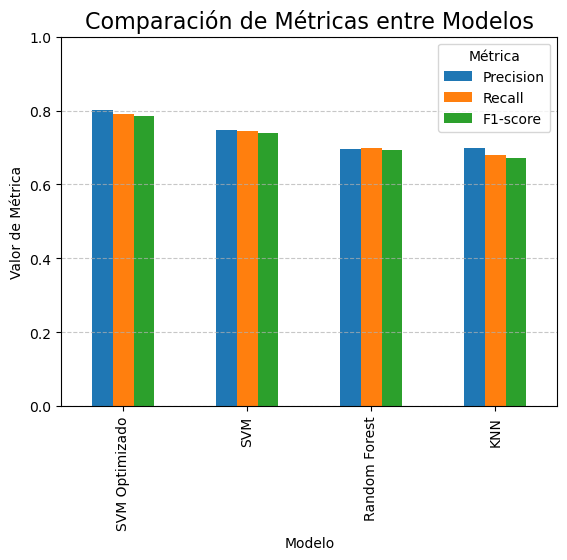

In [9]:
# ==========================
# Gráfico comparativo
# ==========================
import matplotlib.pyplot as plt
df_plot = df_metricas.set_index('Modelo')

plt.figure(figsize=(12, 6))
df_plot.plot(kind='bar')
plt.title('Comparación de Métricas entre Modelos', fontsize=16)
plt.ylabel('Valor de Métrica')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Métrica')
plt.show()


## 7. Conclusiones

En este tercer hito, logramos desarrollar y evaluar exitosamente un sistema de clasificación de géneros musicales utilizando el dataset GTZAN. Tras la extracción de características espectrales y temporales, y la posterior experimentación con múltiples algoritmos, podemos extraer las siguientes conclusiones principales:

* **Supremacía del SVM Optimizado:** El modelo de **Support Vector Machine (SVM)**, tras el ajuste de hiperparámetros (*fine-tuning*) mediante `GridSearchCV`, demostró ser el algoritmo más robusto, alcanzando un **F1-Score cercano al 0.79 (aprox. 80%)**. Esto valida la capacidad del SVM para manejar espacios de características de alta dimensión, típicos en el procesamiento de audio.
* **Impacto de la Optimización:** La búsqueda de rejilla fue determinante. Se observa una mejora clara entre el SVM base y el optimizado (kernel `rbf`, `C=10`, `gamma=0.01`), lo que subraya la importancia de no quedarse con los parámetros por defecto en modelos complejos.
* **Comparativa de Modelos:** Si bien **Random Forest** y **KNN** (nuestra línea base del Hito 2) ofrecieron resultados aceptables (rondando el 0.70), se estancaron en su capacidad de generalización en comparación con el SVM. Esto sugiere que las fronteras de decisión entre géneros musicales en este espacio de características son complejas y no necesariamente lineales ni basadas puramente en vecindad simple.
* **Viabilidad del Pipeline:** El flujo de trabajo implementado desde la extracción de MFCCs y otras características en `librosa` hasta la estandarización y clasificación  demostró ser efectivo para resolver el problema, cumpliendo con los objetivos de la asignatura de Acústica Computacional.



## Referencias Bibliográficas:

1. Lachmish, M. (2021). *MusicGenreClassification* [Repositorio de software]. GitHub. https://github.com/mlachmish/MusicGenreClassification
2. Zapata, J. R. (s.f.). Extracción de características de audio. https://joserzapata.github.io/courses/mineria-audio/extraccion_caracteristicas/
3. Tzanetakis, G., & Cook, P. (2002). Musical genre classification of audio signals. *IEEE Transactions on Speech and Audio Processing*, *10*(5), 293–302. https://doi.org/10.1109/TSA.2002.800560
4. Xu, C., Maddage, N. C., Shao, X., Cao, F., & Tian, Q. (2003). Musical genre classification using support vector machines. En Proceedings of the 2003 IEEE International Conference on Multimedia and Expo (ICME '03) (Vol. 1, pp. I-101-I-104). IEEE. https://doi.org/10.1109/ICME.2003.1221291